# EDA — Part 3: Color data quality and distributions

Examines observed color tokens, data-quality anomalies, and their geographic and contextual distributions.


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path('../../dataset/Capstone2025_nsi_lvl9_with_landcover_and_color.csv.gz')
FIGURES_DIR = Path('../../figures/eda')
TABLES_DIR = Path('../../results/tables/03_color')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pl.read_csv(DATA_PATH)
df

h3,fips,st_damcat,bldgtype,lc_type,loc,clr,clr_cc
str,i64,str,str,str,str,str,i64
"""8929a960d6fffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.828147398273 37.072…","""orange""",8
"""8929a978c07ffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.63428156983 36.9838…","""orange""",8
"""892836da147ffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.464731172229 37.323…","""orange""",11
"""892836c644fffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.787252301526 37.429…","""orange""",12
"""892836d736fffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.716239893409 37.339…","""orange""",1
…,…,…,…,…,…,…,…
"""892836da15bffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.457547536701 37.320…","""olive""",6
"""892836c226bffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.591661571591 37.401…","""olive""",1
"""892836d121bffff""",6047,"""RES""","""M""","""urban+crop""","""POINT(-120.492292055735 37.305…","""olive""",1


In [3]:
clr_counts = df.group_by("clr").agg(pl.col("clr_cc").sum().alias("count")).sort("count", descending=True)
clr_counts = clr_counts.with_columns((pl.col("count") / pl.col("count").sum() * 100).alias("pct"))
clr_counts


clr,count,pct
str,i64,f64
"""cocoa""",2030453,20.871743
"""orange""",722041,7.422114
"""brown""",712253,7.3215
"""terracotta""",700726,7.20301
"""alabaster""",624416,6.418592
…,…,…
"""auburn""",4995,0.051345
"""tan""",4776,0.049094
"""plum""",3600,0.037006


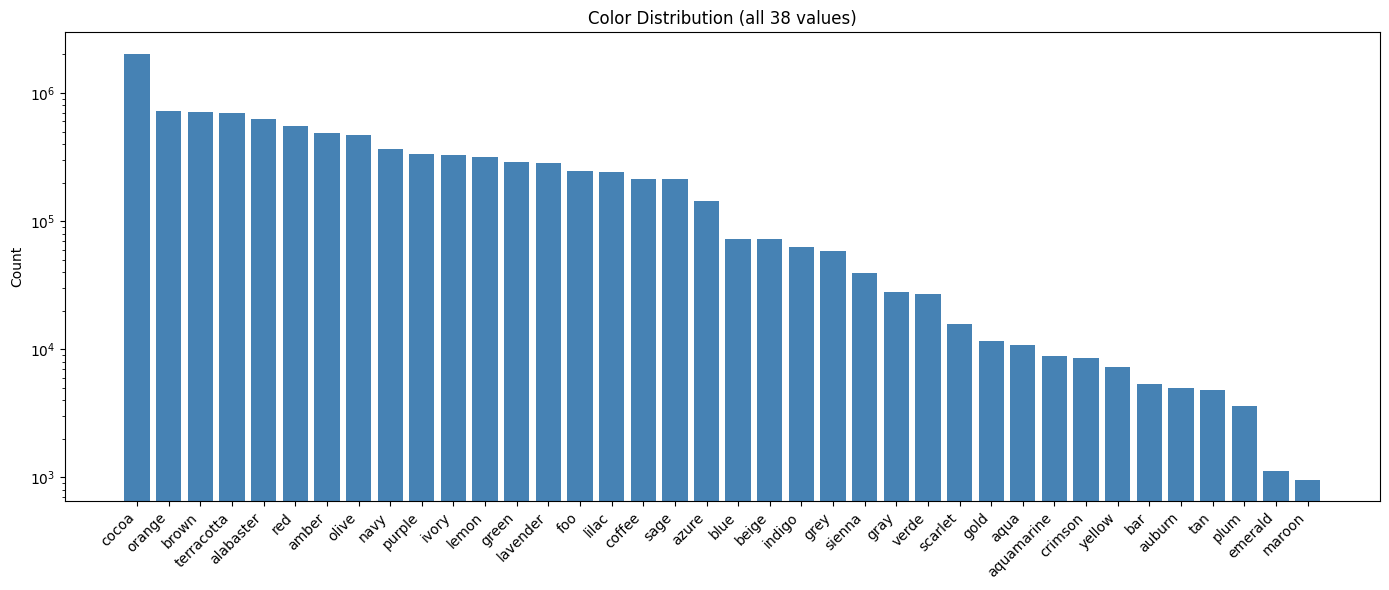

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = clr_counts["clr"].to_list()
counts = clr_counts["count"].to_list()
bars = ax.bar(range(len(colors)), counts, color="steelblue")
ax.set_xticks(range(len(colors)))
ax.set_xticklabels(colors, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Color Distribution (all 38 values)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Unusual color tokens

In [5]:
error_tokens = df.filter(pl.col("clr").is_in(["foo", "bar"]))
foo_count = int(df.filter(pl.col("clr") == "foo")["clr_cc"].sum() or 0)
bar_count = int(df.filter(pl.col("clr") == "bar")["clr_cc"].sum() or 0)
print(f"  foo: {foo_count:,}")
print(f"  bar: {bar_count:,}")


  foo: 245,138
  bar: 5,352


### `foo` placeholder by county

In [6]:
foo_by_county = (
    df.filter(pl.col("clr") == "foo")
    .group_by("fips")
    .agg(pl.col("clr_cc").sum().alias("foo_count"))
)
county_totals = df.group_by("fips").agg(pl.col("clr_cc").sum().alias("total"))
foo_rates = (
    foo_by_county.join(county_totals, on="fips")
    .with_columns((pl.col("foo_count") / pl.col("total") * 100).alias("foo_pct"))
    .sort("foo_pct", descending=True)
)
foo_rates


fips,foo_count,total,foo_pct
i64,i64,i64,f64
6031,5036,34084,14.775261
6113,6188,46380,13.341958
6055,4333,38660,11.207967
6025,3949,36183,10.913965
6103,1318,15368,8.576262
…,…,…,…
6023,31,36158,0.085735
6041,45,76243,0.059022
6045,3,18585,0.016142


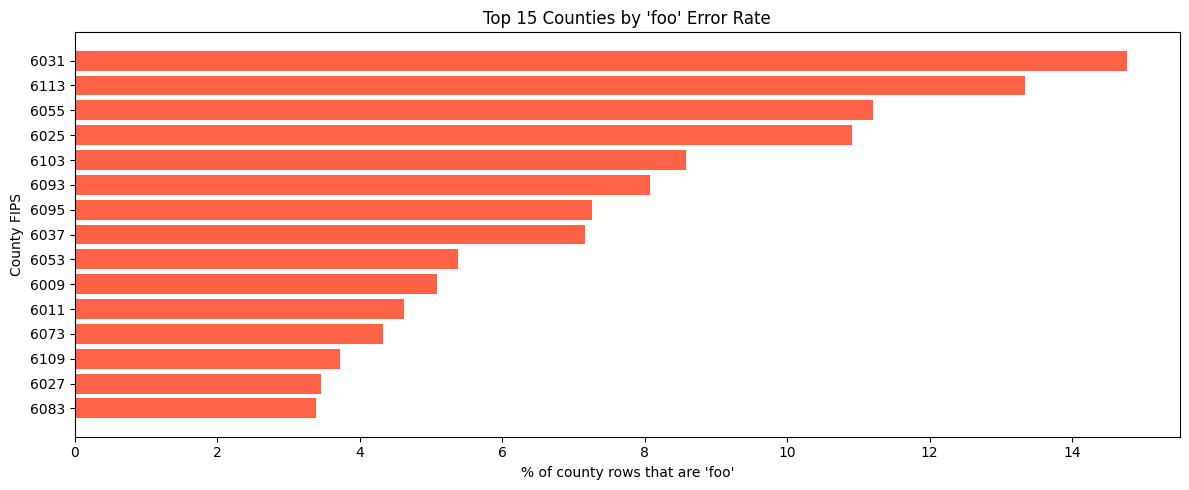

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
top_foo = foo_rates.head(15)
ax.barh(top_foo["fips"].cast(str).to_list()[::-1], top_foo["foo_pct"].to_list()[::-1], color="tomato")
ax.set_xlabel("% of county rows that are 'foo'")
ax.set_ylabel("County FIPS")
ax.set_title("Top 15 Counties by 'foo' Error Rate")
plt.tight_layout()
plt.show()

### `bar` placeholder by county

In [8]:
bar_by_county = (
    df.filter(pl.col("clr") == "bar")
    .group_by("fips")
    .agg(pl.col("clr_cc").sum().alias("bar_count"))
)
county_totals = df.group_by("fips").agg(pl.col("clr_cc").sum().alias("total"))
bar_rates = (
    bar_by_county.join(county_totals, on="fips")
    .with_columns((pl.col("bar_count") / pl.col("total") * 100).alias("bar_pct"))
    .sort("bar_pct", descending=True)
)
bar_rates


fips,bar_count,total,bar_pct
i64,i64,i64,f64
6047,505,67008,0.753641
6021,50,6870,0.727802
6053,635,96480,0.658167
6075,1032,195059,0.529071
6007,264,53258,0.4957
…,…,…,…
6041,137,76243,0.179689
6017,101,59169,0.170697
6063,8,8117,0.098559


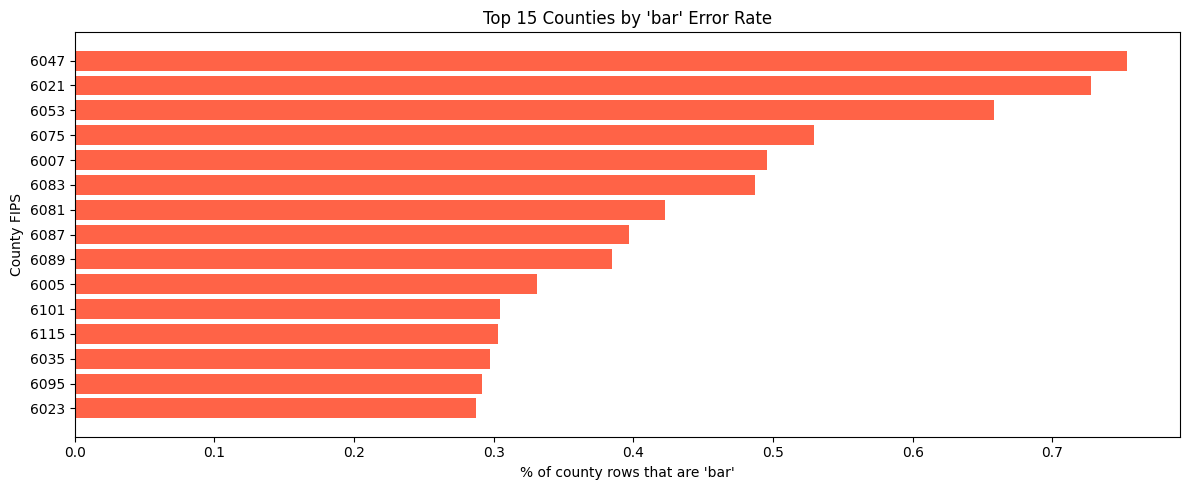

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
top_bar = bar_rates.head(15)
ax.barh(top_bar["fips"].cast(str).to_list()[::-1], top_bar["bar_pct"].to_list()[::-1], color="tomato")
ax.set_xlabel("% of county rows that are 'bar'")
ax.set_ylabel("County FIPS")
ax.set_title("Top 15 Counties by 'bar' Error Rate")
plt.tight_layout()
plt.show()

## Duplicate color labels

In [10]:
duplicates = [("grey", "gray"), ("green", "verde")]
for c1, c2 in duplicates:
    n1 = int(df.filter(pl.col("clr") == c1)["clr_cc"].sum() or 0)
    n2 = int(df.filter(pl.col("clr") == c2)["clr_cc"].sum() or 0)
    ratio = (n1 / n2) if n2 > 0 else float("inf")
    print(f"{c1}: {n1:,} vs {c2}: {n2:,} (ratio {ratio:.2f}x)")


grey: 58,055 vs gray: 27,992 (ratio 2.07x)
green: 292,018 vs verde: 27,146 (ratio 10.76x)


In [11]:
grey_gray = df.filter(pl.col("clr").is_in(["grey", "gray"]))
gg_by_lc = grey_gray.group_by(["lc_type", "clr"]).agg(pl.col("clr_cc").sum().alias("count"))
gg_pivot = gg_by_lc.pivot(on="clr", index="lc_type", values="count").fill_null(0)
gg_pivot


lc_type,gray,grey
str,i64,i64
"""urban+grass""",4669,2148
"""urban+forest""",4287,4843
"""forest""",4578,6271
"""shrub""",994,806
"""crop""",1931,1520
…,…,…
"""urban""",1142,34884
"""barren""",213,94
"""urban+crop""",9225,5684


In [12]:
lc_clr = df.group_by(["lc_type", "clr"]).agg(pl.col("clr_cc").sum().alias("count"))
lc_totals = df.group_by("lc_type").agg(pl.col("clr_cc").sum().alias("lc_total"))
lc_clr = lc_clr.join(lc_totals, on="lc_type")
lc_clr = lc_clr.with_columns((pl.col("count") / pl.col("lc_total") * 100).alias("pct"))
heatmap_data = lc_clr.pivot(on="clr", index="lc_type", values="pct").fill_null(0)
heatmap_data


lc_type,sage,emerald,navy,grey,olive,crimson,tan,auburn,cocoa,aquamarine,green,alabaster,maroon,orange,bar,purple,lilac,ivory,yellow,foo,gray,beige,sienna,blue,verde,red,brown,gold,lavender,aqua,scarlet,terracotta,coffee,azure,plum,indigo,amber,lemon
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""urban+other""",0.222717,0.0,3.786192,1.113586,5.567929,0.0,0.0,0.0,24.498886,0.0,0.890869,6.013363,0.222717,8.908686,0.0,4.008909,4.231626,5.345212,0.445434,4.454343,0.0,0.0,0.668151,0.0,0.0,7.349666,0.890869,0.0,0.445434,0.890869,0.0,7.572383,0.0,1.336303,0.0,0.0,6.904232,4.231626
"""urban+barren""",0.118006,0.001413,9.152514,0.276642,0.710155,0.006713,0.0,0.002826,23.921254,0.060769,3.061791,8.580857,0.00318,17.160654,0.000707,6.113335,0.614407,0.728527,0.022612,0.385109,0.081968,0.513714,0.092214,0.145564,0.0,14.242308,0.318686,0.011306,0.184075,0.091154,0.004946,0.969838,0.123659,0.066776,0.016252,0.292895,10.81484,1.108336
"""grass""",1.80519,0.0,5.910743,1.918014,2.814341,0.006268,0.156701,0.0,23.248088,0.112824,2.162467,24.037859,0.0,7.020183,0.357277,1.134512,0.313401,4.926664,0.0,0.363545,1.253604,0.915131,0.075216,0.206845,0.206845,2.739125,6.092516,0.0,1.491789,0.206845,0.0,2.801805,1.792654,1.993231,0.050144,0.890059,2.682713,0.313401
"""urban+forest""",4.658329,0.032053,1.172007,0.407439,7.61388,0.318177,0.074875,0.006562,16.709951,0.027006,7.298058,5.717519,0.003197,4.074135,0.151769,1.097889,1.102011,1.026715,0.024398,1.157116,0.360663,0.421068,0.178438,0.612126,1.031006,2.493596,17.90644,0.078998,4.794787,0.120726,0.022715,7.96369,4.464243,0.463048,0.067051,1.680906,3.224848,1.442567
"""barren""",0.24883,0.012652,10.197798,0.39644,1.509848,0.0,0.0,0.008435,41.368985,0.851925,3.95597,10.227321,0.004217,12.226393,0.008435,1.729155,0.126524,0.67901,0.03374,0.615748,0.898317,0.991101,0.130741,0.080132,0.0,6.929273,0.649488,0.012652,0.223525,0.19822,0.0,0.400658,0.358483,0.189785,0.025305,0.320526,4.192147,0.19822
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""urban+crop""",3.882221,0.041962,1.918351,1.010651,3.197489,0.701623,0.02027,0.030938,7.954339,0.924948,2.075176,8.191711,0.019736,5.262531,0.11913,3.737309,1.140271,0.10135,0.653082,3.363738,1.640262,0.528974,1.656087,0.756565,0.330542,5.561957,14.512189,0.396686,8.32951,0.442204,0.205011,6.731744,5.962554,2.855924,0.092637,0.98878,4.593624,0.067922
"""crop""",3.451905,0.024055,2.778362,4.570466,2.87759,0.0,0.108248,0.012028,13.564062,1.145623,1.822173,22.605767,0.0,3.343657,1.473374,1.488408,0.294675,0.658508,0.0,0.58935,5.806296,0.784797,0.360826,0.706618,0.132303,1.572601,14.616472,0.0,2.865562,0.27062,0.015034,1.864269,6.239288,2.0086,0.036083,1.142617,0.769763,0.0
"""forest""",6.257654,0.06998,1.747442,1.29072,10.572128,0.0,0.41988,0.000206,13.245776,0.25378,6.98524,7.825824,0.0,3.488504,0.054955,0.591949,0.283007,0.719765,0.0,0.195327,0.94226,0.717089,0.077801,0.80724,2.264677,0.97581,20.263742,0.002882,2.667268,0.335904,0.000412,3.289472,9.741012,0.617677,0.005146,2.190169,1.073782,0.025522


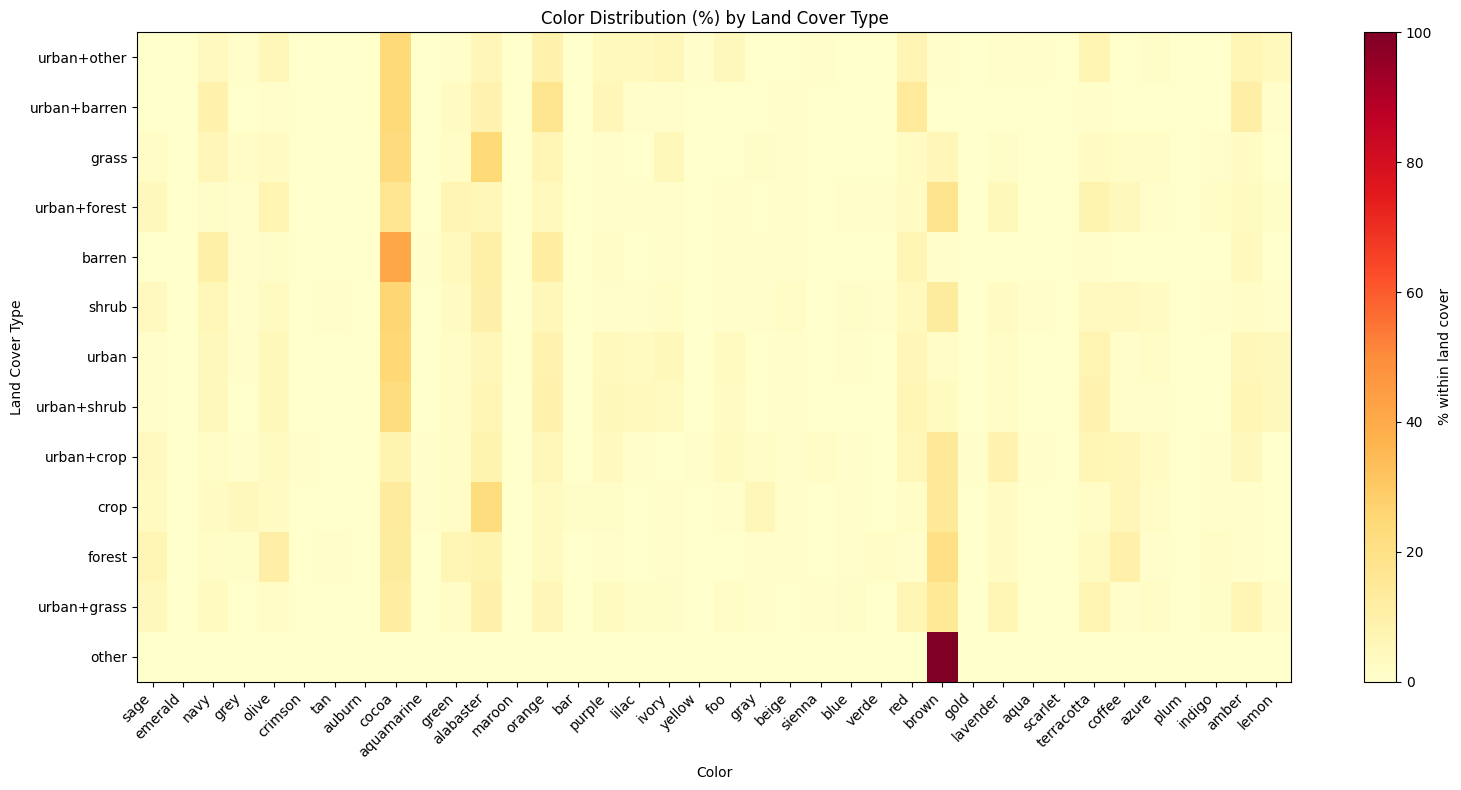

In [13]:
lc_types = heatmap_data["lc_type"].to_list()
color_cols = [c for c in heatmap_data.columns if c != "lc_type"]
matrix = heatmap_data.select(color_cols).to_numpy()

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(color_cols)))
ax.set_xticklabels(color_cols, rotation=45, ha="right")
ax.set_yticks(range(len(lc_types)))
ax.set_yticklabels(lc_types)
ax.set_xlabel("Color")
ax.set_ylabel("Land Cover Type")
ax.set_title("Color Distribution (%) by Land Cover Type")
plt.colorbar(im, ax=ax, label="% within land cover")
plt.tight_layout()
plt.show()

In [14]:
county_color = df.group_by(["fips", "clr"]).agg(pl.col("clr_cc").sum().alias("count"))
county_totals = df.group_by("fips").agg(pl.col("clr_cc").sum().alias("county_total"))
county_color = county_color.join(county_totals, on="fips")
county_color = county_color.with_columns((pl.col("count") / pl.col("county_total") * 100).alias("pct"))
top_color_by_county = county_color.sort(["fips", "pct"], descending=[False, True]).group_by("fips").first()
top_color_by_county.sort("fips")


fips,clr,count,county_total,pct
i64,str,i64,i64,f64
6001,"""cocoa""",112563,393303,28.619919
6003,"""tan""",206,467,44.111349
6005,"""coffee""",4281,10277,41.656125
6007,"""brown""",19015,53258,35.703556
6009,"""cocoa""",5546,16216,34.200789
…,…,…,…,…
6107,"""brown""",40132,110079,36.457453
6109,"""cocoa""",6546,17142,38.186909
6111,"""brown""",74421,219502,33.904475


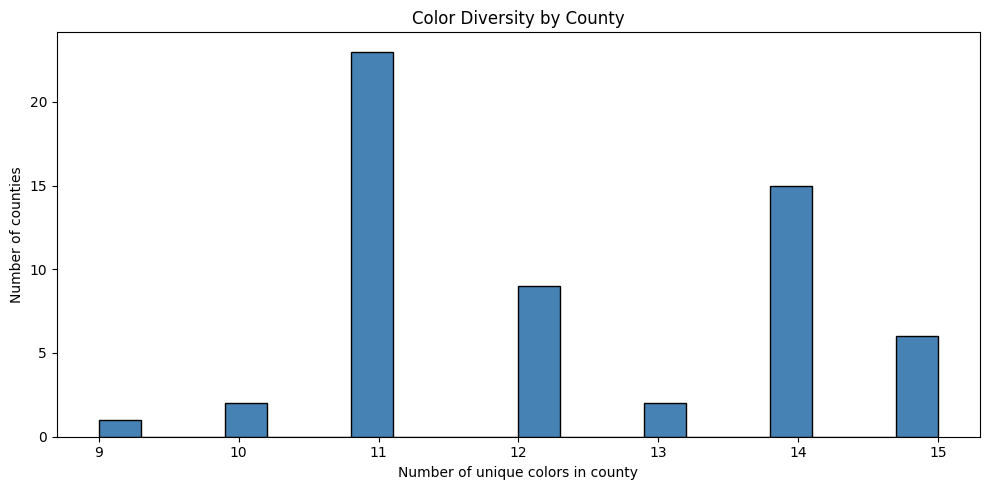

In [15]:
color_diversity = df.group_by("fips").agg(pl.col("clr").n_unique().alias("n_colors"))
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(color_diversity["n_colors"].to_list(), bins=20, color="steelblue", edgecolor="black")
ax.set_xlabel("Number of unique colors in county")
ax.set_ylabel("Number of counties")
ax.set_title("Color Diversity by County")
plt.tight_layout()
plt.show()

In [16]:
bldg_clr = df.group_by(["bldgtype", "clr"]).agg(pl.col("clr_cc").sum().alias("count"))
bldg_totals = df.group_by("bldgtype").agg(pl.col("clr_cc").sum().alias("bldg_total"))
bldg_clr = bldg_clr.join(bldg_totals, on="bldgtype")
bldg_clr = bldg_clr.with_columns((pl.col("count") / pl.col("bldg_total") * 100).alias("pct"))
bldg_pivot = bldg_clr.pivot(on="clr", index="bldgtype", values="pct").fill_null(0)
bldg_pivot


bldgtype,bar,alabaster,coffee,olive,ivory,lavender,crimson,red,blue,orange,cocoa,terracotta,maroon,amber,beige,aqua,grey,sage,yellow,auburn,gold,brown,emerald,lilac,green,purple,navy,indigo,lemon,verde,aquamarine,azure,scarlet,gray,foo,tan,plum,sienna
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""M""",0.028067,6.57611,2.103531,4.850149,3.333855,2.980486,0.089977,5.892642,0.797741,7.551897,20.800753,7.167764,0.005489,5.147169,0.44917,0.109858,0.483084,2.259166,0.077519,0.029595,0.112865,7.290104,0.005991,2.479526,3.071704,3.531184,3.864386,0.589458,3.205787,0.249024,0.094273,1.478393,0.15962,0.293679,2.469025,0.038378,0.02043,0.312151
"""C""",1.109448,0.638574,2.736748,2.399707,1.515317,3.08089,0.002731,3.970742,0.277499,6.550715,20.383035,3.19178,0.238168,3.038828,12.736529,0.003278,5.365337,3.480204,0.018026,1.243281,0.355613,8.800747,0.21741,0.915527,1.356356,1.972534,0.683914,1.888957,3.177577,0.237076,0.002731,0.737447,0.077569,0.359437,0.990364,0.428812,0.709588,5.107503
"""W""",0.026745,6.476104,2.118387,4.9694,3.603262,2.938712,0.088541,5.630058,0.747514,7.252309,20.902253,7.578144,0.003632,5.015787,0.341745,0.11015,0.470273,2.101874,0.07544,0.01886,0.118857,7.199281,0.00636,2.645501,3.031426,3.390968,3.716863,0.643002,3.399234,0.255251,0.088702,1.547795,0.178447,0.275334,2.71153,0.038562,0.016432,0.267269
"""S""",0.889109,1.670174,3.847929,2.570538,1.684805,2.427605,0.005627,3.2807,0.299371,6.17987,25.609715,3.880567,0.124925,2.57504,12.324851,0.028136,3.432636,2.877787,0.011255,0.58186,0.168818,10.671559,0.171069,0.777689,1.364051,1.394438,0.975769,1.116451,2.232902,0.262231,0.027011,0.462562,0.105793,0.274611,0.946507,0.446805,0.694405,3.60483
"""H""",0.007795,8.308385,4.1301,4.572269,1.773282,2.323868,0.148098,6.6584,0.465907,9.4503,20.212227,4.74942,0.0,5.911531,0.89851,0.234194,0.532516,1.518893,0.081135,0.007795,0.046768,7.931761,0.004252,1.487006,3.022197,3.826817,5.049868,0.773796,1.708445,1.177346,0.15235,0.776985,0.012755,0.376269,1.377172,0.022675,0.003189,0.265727


## Rare colors (<1% of records)

In [17]:
rare_colors = clr_counts.filter(pl.col("pct") < 1)["clr"].to_list()
rare_df = df.filter(pl.col("clr").is_in(rare_colors))
rare_by_lc = rare_df.group_by(["clr", "lc_type"]).agg(pl.col("clr_cc").sum().alias("count")).sort(["clr", "count"], descending=[False, True])
rare_by_lc


clr,lc_type,count
str,str,i64
"""aqua""","""urban+grass""",3146
"""aqua""","""urban+crop""",2487
"""aqua""","""forest""",1632
"""aqua""","""urban+forest""",1435
"""aqua""","""shrub""",751
…,…,…
"""yellow""","""urban+shrub""",168
"""yellow""","""urban+barren""",64
"""yellow""","""shrub""",21


Strange colors:
   - 'foo' appears 79,763 times
   - 'bar' appears 4,473 times

2. Duplicate colors:
   - grey (32,094) vs gray (13,665)
   - green (119,011) vs verde (12,742)
